# Analysis 2 — new crawls (Second_analysis/Data) + hashtag classification (post_classification.json)

Everything this notebook needs and produces now lives in this `Second_analysis/` folder:
- `Data/{gender}_{stance}/` — the 6 crawls
- `post_classification.json` and `urls.txt` — the classification input
- all outputs (heatmaps, extended regression table, forest plots) are written here too

Same pipeline as `analysis.ipynb` (comment variation between the 6 crawler accounts, heatmap,
extended regression table, Bayesian beta-binomial model), rebuilt on:

- the **6 new crawls**, much larger than before, in `Data/{gender}_{stance}/`;
- the hashtag-based classification from `post_classification.json` (`pro-life`, `pro-choice`,
  `abortion`, `ambiguous`), replacing the binary `side` field from `urls_to_scrape_500.json` used
  in the first analysis.

Three additions on top of that:

1. **Uniform comment cutoff**: posts range from a handful of comments to over 2000. To remove that
   bias, every account's comments for a post are truncated to the same first N=5 comments, and a post
   is dropped unless all 6 accounts saw at least 5 comments on it. See the dedicated section below for
   why N=5 and not the raw average.
2. **Rank variation**, inspired by the paper *"You See It, They Don't"* (Nutakki, Kempermann & Weber,
   ICWSM 2026): besides whether a comment is visible to each account (presence variation), we check
   whether the **display order** of comments shared by both accounts differs (normalized Kendall
   distance). The paper finds rank variation (0.5-0.7) can be much higher than presence variation
   (0.12), even when the same comments are shown.
3. **MCMC settings matching the paper**: 4 chains, 2000 draws after 2000 tuning steps,
   `target_accept=0.95` (instead of 2 chains / 1000 / 1000).

Forest plots below label each categorical effect with its actual category name (e.g.
`neutral_prolife`, `pro-choice`) instead of a bare index, using PyMC/arviz coordinates.

In [1]:
import os
import json
import pandas as pd
import numpy as np
from itertools import combinations

ANALYSIS_PATH = 'C:/Users/ondob/Desktop/insta_debug/Second_analysis'
DATA_PATH = f'{ANALYSIS_PATH}/Data'
CLASSIFICATION_PATH = f'{ANALYSIS_PATH}/post_classification.json'
OUT_PATH = ANALYSIS_PATH

ACCOUNT_FOLDERS = [
    'male_prolife', 'male_neutral', 'male_prochoice',
    'female_prolife', 'female_neutral', 'female_prochoice',
]

def parse_account_attributes(folder_name):
    parts = folder_name.split('_')
    gender = parts[0]
    account_stance = '_'.join(parts[1:])
    return {'gender': gender, 'account_stance': account_stance}

ACCOUNTS = {folder: parse_account_attributes(folder) for folder in ACCOUNT_FOLDERS}

def load_account_comments(account_folder):
    # New files use 'post_total_comments_count' instead of the old 'post_comments_count' - handle both.
    # We keep the comment set (for presence variation) and the ordered list (for rank variation):
    # list order in the JSON is the display order captured at scrape time.
    folder_path = os.path.join(DATA_PATH, account_folder)
    posts = {}
    for filename in os.listdir(folder_path):
        if filename.endswith('.json') and not filename.startswith('login'):
            post_id = filename.replace('.json', '')
            filepath = os.path.join(folder_path, filename)
            try:
                with open(filepath, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                seen = set()
                comments_ordered = []
                for c in data.get('comments', []):
                    text = c['comment']
                    if text not in seen:
                        seen.add(text)
                        comments_ordered.append(text)
                posts[post_id] = {
                    'comments': set(comments_ordered),
                    'comments_ordered': comments_ordered,
                    'post_comments_count': data.get('post_comments_count', data.get('post_total_comments_count', 0)),
                    'post_total_likes': data.get('post_total_likes', 0),
                    'post_timestamp': data.get('post_timestamp', 'unknown'),
                    'post_publisher_is_verified': data.get('post_publisher_is_verified', False),
                }
            except Exception as e:
                print(f"Error loading {filepath}: {e}")
    return posts

all_accounts_data = {acc: load_account_comments(acc) for acc in ACCOUNT_FOLDERS}

print("Posts per crawl BEFORE filtering:")
for acc, posts in all_accounts_data.items():
    print(f"  {acc}: {len(posts)} posts")

# Step 1: posts common to all 6 crawls
post_sets = [set(posts.keys()) for posts in all_accounts_data.values()]
common_across_crawls = set.intersection(*post_sets)
print(f"\nCommon posts across all {len(ACCOUNT_FOLDERS)} crawls: {len(common_across_crawls)}")

# Step 2: of those, how many are also classified in post_classification.json?
with open(CLASSIFICATION_PATH, 'r', encoding='utf-8') as f:
    classification_data = json.load(f)

classified_ids = set(classification_data.keys())
print(f"Posts in post_classification.json: {len(classified_ids)}")

common_posts = common_across_crawls & classified_ids
missing_classification = common_across_crawls - classified_ids

print(f"\n=== 6 crawls vs classification comparison ===")
print(f"Common to the 6 crawls AND present in post_classification.json: {len(common_posts)}")
print(f"In the 6-crawl intersection but NOT classified: {len(missing_classification)}")
if missing_classification:
    print(f"  -> examples: {sorted(missing_classification)[:10]}")

# keep only posts common to all 6 crawls AND classified
for acc in all_accounts_data:
    all_accounts_data[acc] = {
        post_id: data for post_id, data in all_accounts_data[acc].items()
        if post_id in common_posts
    }

print("\nPosts per crawl AFTER filtering (should all equal len(common_posts)):")
for acc, posts in all_accounts_data.items():
    print(f"  {acc}: {len(posts)} posts")

# hashtag classification replaces the binary 'side' field from the old urls_to_scrape_500.json
url_info = {
    post_id: {
        'post_classification': info.get('classification', 'unknown'),
        'hashtags_found': info.get('hashtags_found', []),
        'url': info.get('url', ''),
    }
    for post_id, info in classification_data.items()
}



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ondob\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\ondob\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\ondob\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\ondob\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ondob\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\ondob\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\ondob\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\ondob\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

FileNotFoundError: [WinError 3] Das System kann den angegebenen Pfad nicht finden: 'C:/Users/ondob/Desktop/insta_debug/Second_analysis/Data\\male_prolife'

## Uniform comment cutoff (first N comments per post)

Posts range from a handful of comments to over 2000. Comparing a post with 5 comments to a post with
2000 comments the same way is not fair: the variation metric behaves very differently depending on
how many comments are available, so mixing both regimes together biases the comparison.

Fix: truncate every account's comments for a given post down to the same first N comments (in
scraped/display order), and keep a post only if ALL 6 accounts saw at least N comments on it. This
makes every compared post strictly uniform: same number of comments, for every account, every time.

The raw mean number of comments per (account, post) is about 55, but that mean is skewed by a
handful of viral posts (median is only 13, one post reaches 2526 comments). Using the raw mean as N
would leave only about 26 posts (4%) usable across all 6 accounts — too little data to model anything.
N=5 is used instead: the largest value at or above a floor of 5 comments that still keeps the dataset
usable (~471 of 612 posts, ~77%), while guaranteeing a real, uniform sample compared across every
account for every post.

In [ ]:
# uniform N-comment cutoff, applied identically across all 6 crawls

# diagnostic: distribution of comment counts per (account, post), before truncation
raw_counts = np.array([
    len(data['comments_ordered'])
    for posts in all_accounts_data.values()
    for post_id, data in posts.items()
    if post_id in common_posts
])
print("Comment count per (account, post), before truncation:")
print(f"  mean={raw_counts.mean():.1f}  median={np.median(raw_counts):.0f}  "
      f"min={raw_counts.min()}  max={raw_counts.max()}")

TOP_N_COMMENTS = 5  # chosen floor - the raw mean (~55) would only keep ~4% of posts, see markdown above

# a post is kept only if every one of the 6 accounts saw at least N comments on it
post_min_count = {
    post_id: min(len(all_accounts_data[acc][post_id]['comments_ordered']) for acc in ACCOUNT_FOLDERS)
    for post_id in common_posts
}
common_posts = {post_id for post_id, min_count in post_min_count.items() if min_count >= TOP_N_COMMENTS}
print(f"\nN = {TOP_N_COMMENTS}")
print(f"Posts with >= {TOP_N_COMMENTS} comments on ALL 6 accounts: {len(common_posts)} / {len(post_min_count)}")

# truncate every account's comments to the first N, keeping only the surviving posts
for acc in all_accounts_data:
    all_accounts_data[acc] = {
        post_id: {
            **data,
            'comments_ordered': data['comments_ordered'][:TOP_N_COMMENTS],
            'comments': set(data['comments_ordered'][:TOP_N_COMMENTS]),
        }
        for post_id, data in all_accounts_data[acc].items()
        if post_id in common_posts
    }

print(f"\nPosts per crawl AFTER truncation to the first {TOP_N_COMMENTS} comments:")
for acc, posts in all_accounts_data.items():
    print(f"  {acc}: {len(posts)} posts")


In [ ]:
def compute_variation(comments_a, comments_b):
    if len(comments_a) == 0 and len(comments_b) == 0:
        return None
    total = len(comments_a) + len(comments_b)
    if total == 0:
        return None
    symmetric_diff = comments_a.symmetric_difference(comments_b)
    return len(symmetric_diff) / total

def compute_pairwise_variation(all_accounts_data):
    account_names = list(all_accounts_data.keys())
    results = []
    for acc_a, acc_b in combinations(account_names, 2):
        posts_a = all_accounts_data[acc_a]
        posts_b = all_accounts_data[acc_b]
        # posts are already restricted to the common set, so this intersection is just a safety check
        shared = set(posts_a.keys()) & set(posts_b.keys())
        variations = [
            compute_variation(posts_a[p]['comments'], posts_b[p]['comments'])
            for p in shared
        ]
        variations = [v for v in variations if v is not None]
        if variations:
            results.append({
                'account_a': acc_a, 'account_b': acc_b,
                'avg_variation': np.mean(variations), 'n_posts': len(variations)
            })
    return pd.DataFrame(results)

pairwise_summary = compute_pairwise_variation(all_accounts_data)
print(pairwise_summary)

avg_of_pair_averages = pairwise_summary['avg_variation'].mean()
print(f"\nAverage of per-pair averages: {avg_of_pair_averages:.2%}")


         account_a         account_b  avg_variation  n_posts
0     male_prolife      male_neutral       0.174185      611
1     male_prolife    male_prochoice       0.192560      612
2     male_prolife    female_prolife       0.116540      611
3     male_prolife    female_neutral       0.130398      611
4     male_prolife  female_prochoice       0.092996      611
5     male_neutral    male_prochoice       0.189484      612
6     male_neutral    female_prolife       0.163803      611
7     male_neutral    female_neutral       0.157212      611
8     male_neutral  female_prochoice       0.171136      611
9   male_prochoice    female_prolife       0.191294      612
10  male_prochoice    female_neutral       0.191098      612
11  male_prochoice  female_prochoice       0.184208      612
12  female_prolife    female_neutral       0.143008      611
13  female_prolife  female_prochoice       0.126527      611
14  female_neutral  female_prochoice       0.136484      611

Average of per-pair ave

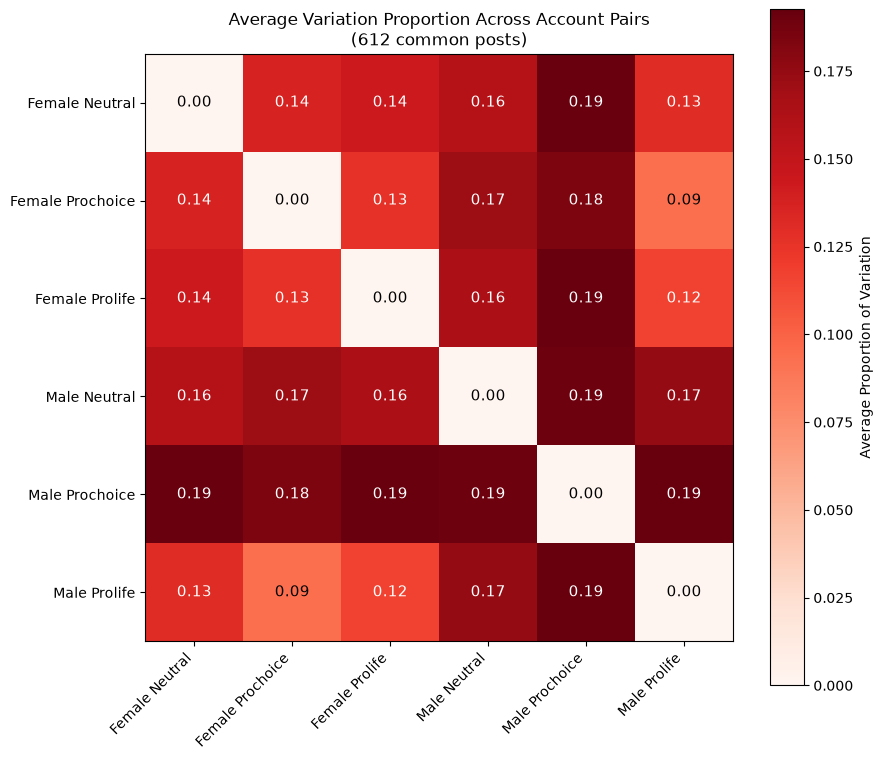

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

N_COMMON = len(common_posts)

def build_heatmap_matrix(pairwise_df, value_col, account_names=None):
    if account_names is None:
        account_names = sorted(set(pairwise_df['account_a']) | set(pairwise_df['account_b']))

    labels = {a: a.replace('_', ' ').title() for a in account_names}
    n = len(account_names)
    idx_map = {name: i for i, name in enumerate(account_names)}
    arr = np.zeros((n, n), dtype=float)

    for _, row in pairwise_df.iterrows():
        i = idx_map[row['account_a']]
        j = idx_map[row['account_b']]
        arr[i, j] = row[value_col]
        arr[j, i] = row[value_col]

    np.fill_diagonal(arr, 0)

    display_labels = [labels[a] for a in account_names]
    return arr, display_labels

def plot_variation_heatmap(pairwise_df, value_col, title, out_file, cbar_label='Average Proportion of Variation'):
    heatmap_arr, display_labels = build_heatmap_matrix(pairwise_df, value_col)
    n = len(display_labels)

    fig, ax = plt.subplots(figsize=(9, 8))

    # plain matplotlib imshow - bypasses seaborn entirely
    im = ax.imshow(heatmap_arr, cmap="Reds", vmin=0, vmax=heatmap_arr.max())

    # manual text annotations, cell by cell - guaranteed to render on every cell
    threshold = heatmap_arr.max() / 2
    for i in range(n):
        for j in range(n):
            value = heatmap_arr[i, j]
            text_color = "white" if value > threshold else "black"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                     color=text_color, fontsize=11)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(display_labels, rotation=45, ha='right')
    ax.set_yticklabels(display_labels)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_file, dpi=200)
    plt.show()

plot_variation_heatmap(
    pairwise_summary, 'avg_variation',
    title=f"Average Variation Proportion Across Account Pairs\n({N_COMMON} common posts)",
    out_file=f'{OUT_PATH}/variation_heatmap_v2.png',
)


## Rank variation (comment display order)

Even when two accounts see the same set of comments, Instagram can show them in a different order.
For each pair of accounts and each post, we take the comments **shared** by both accounts and measure
how different their relative order is, using the normalized Kendall distance:

- 0 = identical order
- 1 = perfectly reversed order
- ~0.5 = uncorrelated order (random relative to each other)

This mirrors the reference paper's approach ("considering difference in rank as variation"), which
finds rank variation (0.5-0.7) much higher than presence variation (0.12).

In [ ]:
from scipy.stats import kendalltau

def compute_rank_variation(ordered_a, ordered_b):
    # Returns (n_discordant, n_pairs, proportion) over the comments shared by both accounts.
    # None if fewer than 2 shared comments (nothing to compare).
    shared = set(ordered_a) & set(ordered_b)
    n = len(shared)
    if n < 2:
        return None, None, None
    rank_a = {c: i for i, c in enumerate(ordered_a)}
    rank_b = {c: i for i, c in enumerate(ordered_b)}
    ra = np.array([rank_a[c] for c in shared])
    rb = np.array([rank_b[c] for c in shared])
    tau, _ = kendalltau(ra, rb)
    n_pairs = n * (n - 1) // 2
    n_discordant = int(round(n_pairs * (1 - tau) / 2))
    n_discordant = min(max(n_discordant, 0), n_pairs)  # guard against rounding drift
    return n_discordant, n_pairs, n_discordant / n_pairs

def compute_pairwise_rank_variation(all_accounts_data):
    account_names = list(all_accounts_data.keys())
    results = []
    for acc_a, acc_b in combinations(account_names, 2):
        posts_a = all_accounts_data[acc_a]
        posts_b = all_accounts_data[acc_b]
        shared_posts = set(posts_a.keys()) & set(posts_b.keys())
        props = []
        for p in shared_posts:
            _, _, prop = compute_rank_variation(posts_a[p]['comments_ordered'], posts_b[p]['comments_ordered'])
            if prop is not None:
                props.append(prop)
        if props:
            results.append({
                'account_a': acc_a, 'account_b': acc_b,
                'avg_rank_variation': np.mean(props), 'n_posts': len(props)
            })
    return pd.DataFrame(results)

pairwise_rank_summary = compute_pairwise_rank_variation(all_accounts_data)
print(pairwise_rank_summary)

avg_rank_variation = pairwise_rank_summary['avg_rank_variation'].mean()
print(f"\nAverage of per-pair rank-variation averages: {avg_rank_variation:.2%}")


         account_a         account_b  avg_rank_variation  n_posts
0     male_prolife      male_neutral            0.092592      595
1     male_prolife    male_prochoice            0.123382      596
2     male_prolife    female_prolife            0.065407      596
3     male_prolife    female_neutral            0.076061      597
4     male_prolife  female_prochoice            0.067731      596
5     male_neutral    male_prochoice            0.117187      595
6     male_neutral    female_prolife            0.091746      592
7     male_neutral    female_neutral            0.104380      594
8     male_neutral  female_prochoice            0.090813      592
9   male_prochoice    female_prolife            0.114420      594
10  male_prochoice    female_neutral            0.110685      596
11  male_prochoice  female_prochoice            0.113816      594
12  female_prolife    female_neutral            0.059694      597
13  female_prolife  female_prochoice            0.037461      599
14  female

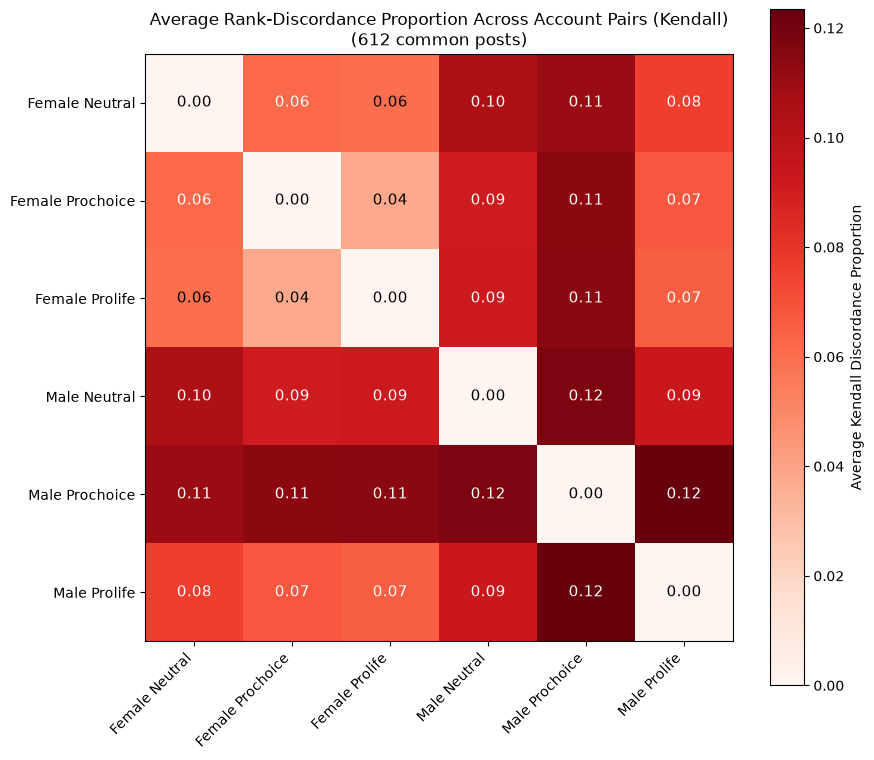

In [ ]:
plot_variation_heatmap(
    pairwise_rank_summary, 'avg_rank_variation',
    title=f"Average Rank-Discordance Proportion Across Account Pairs (Kendall)\n({N_COMMON} common posts)",
    out_file=f'{OUT_PATH}/rank_variation_heatmap_v2.png',
    cbar_label='Average Kendall Discordance Proportion',
)


In [ ]:
def build_extended_regression_table(all_accounts_data, url_info, accounts_meta):
    # Post-pair-level table with descriptive/diagnostic columns beyond the basic V/T variation metric.
    # post_classification (pro-life / pro-choice / abortion / ambiguous) replaces the old binary
    # 'side' field. Also adds RANK variation metrics (n_rank_pairs / n_discordant_pairs /
    # rank_variation_proportion).
    account_names = list(all_accounts_data.keys())
    rows = []

    for acc_a, acc_b in combinations(account_names, 2):
        posts_a = all_accounts_data[acc_a]
        posts_b = all_accounts_data[acc_b]
        shared = set(posts_a.keys()) & set(posts_b.keys())

        meta_a = accounts_meta[acc_a]
        meta_b = accounts_meta[acc_b]

        stance_pair = '_'.join(sorted([meta_a['account_stance'], meta_b['account_stance']]))
        gender_pair = '_'.join(sorted([meta_a['gender'], meta_b['gender']]))

        for post_id in shared:
            data_a = posts_a[post_id]
            data_b = posts_b[post_id]
            ca = data_a['comments']
            cb = data_b['comments']

            total = len(ca) + len(cb)
            if total == 0:
                continue

            intersection = ca & cb
            symmetric_diff = ca.symmetric_difference(cb)

            info = url_info.get(post_id, {})
            post_classification = info.get('post_classification', 'unknown')
            hashtags_found = ';'.join(info.get('hashtags_found', []))

            n_discordant, n_rank_pairs, rank_variation_proportion = compute_rank_variation(
                data_a['comments_ordered'], data_b['comments_ordered']
            )

            rows.append({
                # === identifiers ===
                'post_id': post_id,
                'account_a': acc_a,
                'account_b': acc_b,
                'account_pair': f"{acc_a}_{acc_b}",
                'post_timestamp': data_a.get('post_timestamp', 'unknown'),

                # === account attributes ===
                'gender_a': meta_a['gender'],
                'gender_b': meta_b['gender'],
                'stance_a': meta_a['account_stance'],
                'stance_b': meta_b['account_stance'],
                'gender_pair': gender_pair,
                'stance_pair': stance_pair,
                'same_stance': meta_a['account_stance'] == meta_b['account_stance'],
                'same_gender': meta_a['gender'] == meta_b['gender'],
                'opposite_stance': (
                    {meta_a['account_stance'], meta_b['account_stance']} == {'prolife', 'prochoice'}
                ),

                # === post-level content attributes (hashtag-based classification) ===
                'post_classification': post_classification,
                'post_hashtags_found': hashtags_found,
                'post_total_likes': data_a.get('post_total_likes', 0),
                'post_publisher_is_verified': data_a.get('post_publisher_is_verified', False),
                'post_comments_count': data_a.get('post_comments_count', 0),

                # === comment counts seen by each account ===
                'n_comments_seen_a': len(ca),
                'n_comments_seen_b': len(cb),
                'n_comments_shared': len(intersection),
                'n_comments_unique_a': len(ca - cb),
                'n_comments_unique_b': len(cb - ca),

                # === core variation metrics: PRESENCE (paper's V/T formula) ===
                'V': len(symmetric_diff),
                'T': total,
                'variation_proportion': len(symmetric_diff) / total,

                # === core variation metrics: RANK (Kendall discordance among shared comments) ===
                'n_discordant_pairs': n_discordant,
                'n_rank_pairs': n_rank_pairs,
                'rank_variation_proportion': rank_variation_proportion,

                # === comment length stats (proxy for content depth) ===
                'avg_comment_length_a': (
                    np.mean([len(c) for c in ca]) if ca else 0
                ),
                'avg_comment_length_b': (
                    np.mean([len(c) for c in cb]) if cb else 0
                ),
            })

    return pd.DataFrame(rows)

extended_df = build_extended_regression_table(all_accounts_data, url_info, ACCOUNTS)

from datetime import datetime, timezone

def compute_post_age_days(timestamp_str):
    # Age of the post in days, from its ISO timestamp.
    if timestamp_str == 'unknown':
        return None
    try:
        post_time = datetime.fromisoformat(timestamp_str.replace('Z', '+00:00'))
        now = datetime.now(timezone.utc)
        return (now - post_time).total_seconds() / 86400
    except Exception:
        return None

extended_df['post_age_days'] = extended_df['post_timestamp'].apply(compute_post_age_days)

# standardize for the model (same treatment as comments/likes)
extended_df['log_post_age_z'] = (
    np.log1p(extended_df['post_age_days'].fillna(extended_df['post_age_days'].median()))
    - np.log1p(extended_df['post_age_days']).mean()
) / np.log1p(extended_df['post_age_days']).std()

# log-transform and standardize continuous covariates
extended_df['log_comments_z'] = (
    np.log1p(extended_df['post_comments_count']) - np.log1p(extended_df['post_comments_count']).mean()
) / np.log1p(extended_df['post_comments_count']).std()

extended_df['log_likes_z'] = (
    np.log1p(extended_df['post_total_likes']) - np.log1p(extended_df['post_total_likes']).mean()
) / np.log1p(extended_df['post_total_likes']).std()

extended_df.to_csv(f'{OUT_PATH}/extended_regression_table_v2.csv', index=False)
print(extended_df.head())
print(f"\nTotal observations: {len(extended_df)}")
print(f"Rows with usable rank data (n_rank_pairs not null): {extended_df['n_rank_pairs'].notna().sum()} / {len(extended_df)}")
print(f"Columns: {list(extended_df.columns)}")
print(f"\npost_classification distribution:")
print(extended_df['post_classification'].value_counts())


       post_id     account_a     account_b               account_pair  \
0  DYvNlPaDcoe  male_prolife  male_neutral  male_prolife_male_neutral   
1  Ch-hDqDOUU1  male_prolife  male_neutral  male_prolife_male_neutral   
2  DW5MWrJGob0  male_prolife  male_neutral  male_prolife_male_neutral   
3  DCCNT9DubCr  male_prolife  male_neutral  male_prolife_male_neutral   
4  DYdlXiEAWnQ  male_prolife  male_neutral  male_prolife_male_neutral   

             post_timestamp gender_a gender_b stance_a stance_b gender_pair  \
0  2026-05-24T22:11:08.000Z     male     male  prolife  neutral   male_male   
1  2022-09-01T20:03:15.000Z     male     male  prolife  neutral   male_male   
2  2026-04-09T02:10:08.000Z     male     male  prolife  neutral   male_male   
3  2024-11-06T15:12:17.000Z     male     male  prolife  neutral   male_male   
4  2026-05-18T01:54:10.000Z     male     male  prolife  neutral   male_male   

   ... variation_proportion  n_discordant_pairs  n_rank_pairs  \
0  ...             0.

## Bayesian beta-binomial models

Two models sharing the same covariate structure. `beta_post_side` (the binary pro-life/pro-choice
variable from the first analysis) is replaced by `beta_post_classification`, a 4-level categorical
effect (`pro-life`, `pro-choice`, `abortion`, `ambiguous`) from `post_classification.json`.

1. **Presence model**: `V` (comments that differ) out of `T` (total seen by both accounts) — same as
   `analysis.ipynb`, on the new data.
2. **Rank model**: `n_discordant_pairs` out of `n_rank_pairs` — new, checks whether the **order** of
   shared comments differs between accounts (see previous section).

MCMC settings matching the reference paper: **4 chains, 2000 draws after 2000 tuning steps,
`target_accept=0.95`** (instead of 2 chains / 1000 / 1000 in the previous version). With ~9000
observations and a per-post random effect, this is noticeably more expensive: expect several tens of
minutes per model depending on the machine.

Each categorical effect (`beta_stance_pair`, `beta_gender_pair`, `beta_post_classification`) is
declared with named PyMC/arviz coordinates, so the forest plots and summary tables show the actual
category label (e.g. `beta_stance_pair[neutral_prolife]`) instead of a bare index.

In [ ]:
import pandas as pd
import numpy as np

reg_df = pd.read_csv(f'{OUT_PATH}/extended_regression_table_v2.csv')
print(f"reg_df reloaded: {len(reg_df)} rows")


reg_df reloaded: 9170 rows


In [ ]:
import pymc as pm
import arviz as az

MCMC_KWARGS = dict(draws=2000, tune=2000, chains=4, random_seed=42, target_accept=0.95, nuts_sampler="nutpie")

reg_df['post_idx'] = pd.factorize(reg_df['post_id'])[0]
reg_df['stance_pair_idx'] = pd.factorize(reg_df['stance_pair'])[0]
reg_df['gender_pair_idx'] = pd.factorize(reg_df['gender_pair'])[0]
reg_df['post_classification_idx'] = pd.factorize(reg_df['post_classification'])[0]

n_posts = reg_df['post_idx'].nunique()

stance_pair_labels = list(pd.factorize(reg_df['stance_pair'])[1])
gender_pair_labels = list(pd.factorize(reg_df['gender_pair'])[1])
post_classification_labels = list(pd.factorize(reg_df['post_classification'])[1])

# named coordinates so arviz shows category names (e.g. "beta_stance_pair[neutral_prolife]")
# instead of a bare index ("beta_stance_pair[0]") in the summary table and forest plot
coords = {
    'stance_pair': stance_pair_labels,
    'gender_pair': gender_pair_labels,
    'post_classification': post_classification_labels,
}

with pm.Model(coords=coords) as beta_binomial_model:
    intercept = pm.Normal('intercept', mu=0, sigma=2)
    beta_comments = pm.Normal('beta_comments', mu=0, sigma=2)
    beta_likes = pm.Normal('beta_likes', mu=0, sigma=2)
    beta_post_age = pm.Normal('beta_post_age', mu=0, sigma=2)
    beta_stance_pair = pm.Normal('beta_stance_pair', mu=0, sigma=2, dims='stance_pair')
    beta_gender_pair = pm.Normal('beta_gender_pair', mu=0, sigma=2, dims='gender_pair')
    beta_post_classification = pm.Normal('beta_post_classification', mu=0, sigma=2, dims='post_classification')

    post_sigma = pm.HalfNormal('post_sigma', sigma=1)
    post_effect = pm.Normal('post_effect', mu=0, sigma=post_sigma, shape=n_posts)

    logit_p = (
        intercept
        + beta_comments * reg_df['log_comments_z'].values
        + beta_likes * reg_df['log_likes_z'].values
        + beta_post_age * reg_df['log_post_age_z'].values
        + beta_stance_pair[reg_df['stance_pair_idx'].values]
        + beta_gender_pair[reg_df['gender_pair_idx'].values]
        + beta_post_classification[reg_df['post_classification_idx'].values]
        + post_effect[reg_df['post_idx'].values]
    )
    p = pm.Deterministic('p', pm.math.sigmoid(logit_p))

    kappa = pm.HalfNormal('kappa', sigma=10)
    alpha = p * kappa
    beta_param = (1 - p) * kappa

    V_obs = pm.BetaBinomial(
        'V_obs', alpha=alpha, beta=beta_param,
        n=reg_df['T'].values, observed=reg_df['V'].values
    )

    trace = pm.sample(**MCMC_KWARGS)

summary = az.summary(trace, var_names=[
    'intercept', 'beta_comments', 'beta_likes',
    'beta_stance_pair', 'beta_gender_pair', 'beta_post_classification', 'beta_post_age'
])
summary['odds_ratio'] = np.exp(summary['mean'])
print(summary[['mean', 'odds_ratio', 'hdi_3%', 'hdi_97%', 'r_hat']])


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ondob\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <modul

Progress,Draws,Divergences,Step Size,Gradients/Draw
,4000,0,0.07,63
,4000,0,0.08,63
,4000,0,0.08,63
,4000,0,0.07,63


                                        mean  odds_ratio  hdi_3%  hdi_97%  \
intercept                             -1.666    0.189002  -4.299    0.857   
beta_comments                          1.278    3.589454   1.030    1.518   
beta_likes                             0.167    1.181754  -0.059    0.406   
beta_stance_pair[neutral_prolife]     -0.201    0.817912  -1.607    1.233   
beta_stance_pair[prochoice_prolife]   -0.290    0.748264  -1.662    1.181   
beta_stance_pair[prolife_prolife]     -0.621    0.537407  -1.974    0.871   
beta_stance_pair[neutral_prochoice]   -0.023    0.977262  -1.436    1.403   
beta_stance_pair[neutral_neutral]     -0.092    0.912105  -1.429    1.412   
beta_stance_pair[prochoice_prochoice]  0.059    1.060775  -1.277    1.575   
beta_gender_pair[male_male]           -0.285    0.752014  -2.264    1.631   
beta_gender_pair[female_male]         -0.548    0.578105  -2.515    1.379   
beta_gender_pair[female_female]       -0.806    0.446641  -2.737    1.145   

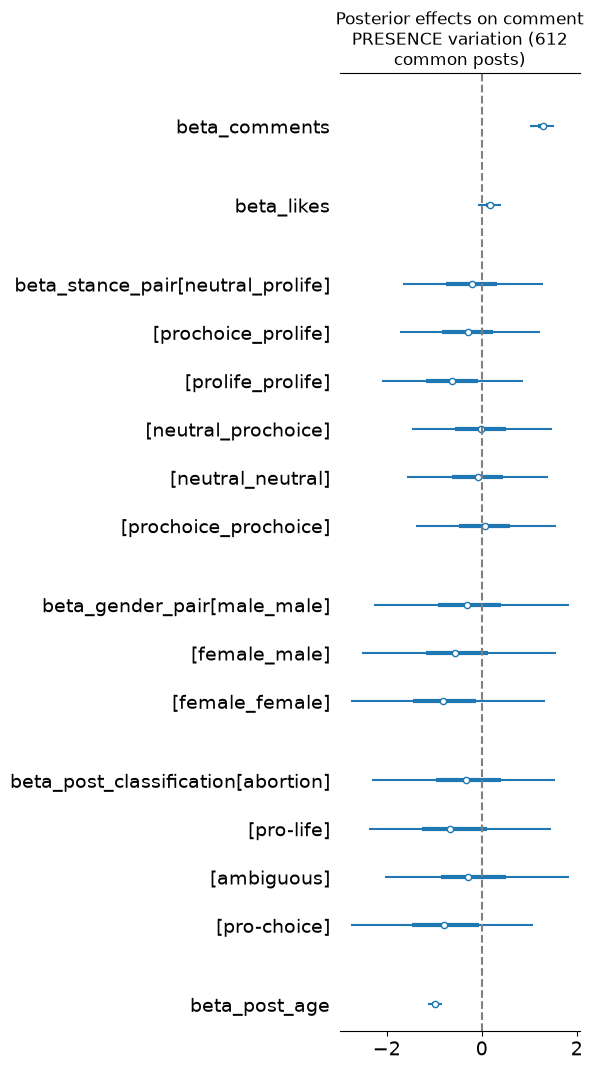

In [ ]:
import matplotlib.pyplot as plt

az.plot_forest(
    trace, var_names=['beta_comments', 'beta_likes',
                       'beta_stance_pair', 'beta_gender_pair', 'beta_post_classification', 'beta_post_age'],
    combined=True, hdi_prob=0.95
)
plt.axvline(0, linestyle='--', color='gray')
plt.title(f"Posterior effects on comment PRESENCE variation ({reg_df['post_id'].nunique()} common posts)")
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/forest_plot_v2.png', dpi=200)
plt.show()


## RANK variation model

Same covariate structure as the presence model above, but the observed outcome is now
`n_discordant_pairs` (pairs of shared comments whose relative order differs between the two accounts)
out of `n_rank_pairs` (total comparable pairs). Rows without usable rank data (fewer than 2 shared
comments) are dropped.

In [ ]:
rank_reg_df = reg_df.dropna(subset=['n_rank_pairs', 'n_discordant_pairs']).copy()
rank_reg_df = rank_reg_df[rank_reg_df['n_rank_pairs'] >= 1].reset_index(drop=True)
print(f"rank_reg_df: {len(rank_reg_df)} rows (out of {len(reg_df)} total)")

rank_reg_df['post_idx'] = pd.factorize(rank_reg_df['post_id'])[0]
rank_reg_df['stance_pair_idx'] = pd.factorize(rank_reg_df['stance_pair'])[0]
rank_reg_df['gender_pair_idx'] = pd.factorize(rank_reg_df['gender_pair'])[0]
rank_reg_df['post_classification_idx'] = pd.factorize(rank_reg_df['post_classification'])[0]

n_posts_rank = rank_reg_df['post_idx'].nunique()

rank_coords = {
    'stance_pair': list(pd.factorize(rank_reg_df['stance_pair'])[1]),
    'gender_pair': list(pd.factorize(rank_reg_df['gender_pair'])[1]),
    'post_classification': list(pd.factorize(rank_reg_df['post_classification'])[1]),
}

with pm.Model(coords=rank_coords) as rank_beta_binomial_model:
    intercept = pm.Normal('intercept', mu=0, sigma=2)
    beta_comments = pm.Normal('beta_comments', mu=0, sigma=2)
    beta_likes = pm.Normal('beta_likes', mu=0, sigma=2)
    beta_post_age = pm.Normal('beta_post_age', mu=0, sigma=2)
    beta_stance_pair = pm.Normal('beta_stance_pair', mu=0, sigma=2, dims='stance_pair')
    beta_gender_pair = pm.Normal('beta_gender_pair', mu=0, sigma=2, dims='gender_pair')
    beta_post_classification = pm.Normal('beta_post_classification', mu=0, sigma=2, dims='post_classification')

    post_sigma = pm.HalfNormal('post_sigma', sigma=1)
    post_effect = pm.Normal('post_effect', mu=0, sigma=post_sigma, shape=n_posts_rank)

    logit_p = (
        intercept
        + beta_comments * rank_reg_df['log_comments_z'].values
        + beta_likes * rank_reg_df['log_likes_z'].values
        + beta_post_age * rank_reg_df['log_post_age_z'].values
        + beta_stance_pair[rank_reg_df['stance_pair_idx'].values]
        + beta_gender_pair[rank_reg_df['gender_pair_idx'].values]
        + beta_post_classification[rank_reg_df['post_classification_idx'].values]
        + post_effect[rank_reg_df['post_idx'].values]
    )
    p = pm.Deterministic('p', pm.math.sigmoid(logit_p))

    kappa = pm.HalfNormal('kappa', sigma=10)
    alpha = p * kappa
    beta_param = (1 - p) * kappa

    V_rank_obs = pm.BetaBinomial(
        'V_rank_obs', alpha=alpha, beta=beta_param,
        n=rank_reg_df['n_rank_pairs'].values, observed=rank_reg_df['n_discordant_pairs'].values
    )

    rank_trace = pm.sample(**MCMC_KWARGS)

rank_summary = az.summary(rank_trace, var_names=[
    'intercept', 'beta_comments', 'beta_likes',
    'beta_stance_pair', 'beta_gender_pair', 'beta_post_classification', 'beta_post_age'
])
rank_summary['odds_ratio'] = np.exp(rank_summary['mean'])
print(rank_summary[['mean', 'odds_ratio', 'hdi_3%', 'hdi_97%', 'r_hat']])


rank_reg_df: 8930 rows (out of 9170 total)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,4000,0,0.06,63
,4000,0,0.08,63
,4000,0,0.08,63
,4000,0,0.07,63


                                        mean  odds_ratio  hdi_3%  hdi_97%  \
intercept                             -2.315    0.098766  -4.791   -0.112   
beta_comments                         -0.050    0.951229  -0.335    0.225   
beta_likes                            -0.176    0.838618  -0.457    0.113   
beta_stance_pair[neutral_prolife]     -0.669    0.512221  -1.891    0.858   
beta_stance_pair[prochoice_prolife]   -0.644    0.525187  -1.922    0.836   
beta_stance_pair[prolife_prolife]     -0.952    0.385968  -2.157    0.603   
beta_stance_pair[neutral_prochoice]   -0.426    0.653116  -1.630    1.122   
beta_stance_pair[neutral_neutral]     -0.384    0.681131  -1.598    1.153   
beta_stance_pair[prochoice_prochoice] -0.319    0.726876  -1.538    1.224   
beta_gender_pair[male_male]           -0.295    0.744532  -1.982    1.426   
beta_gender_pair[female_male]         -0.599    0.549361  -2.290    1.117   
beta_gender_pair[female_female]       -1.219    0.295526  -2.902    0.518   

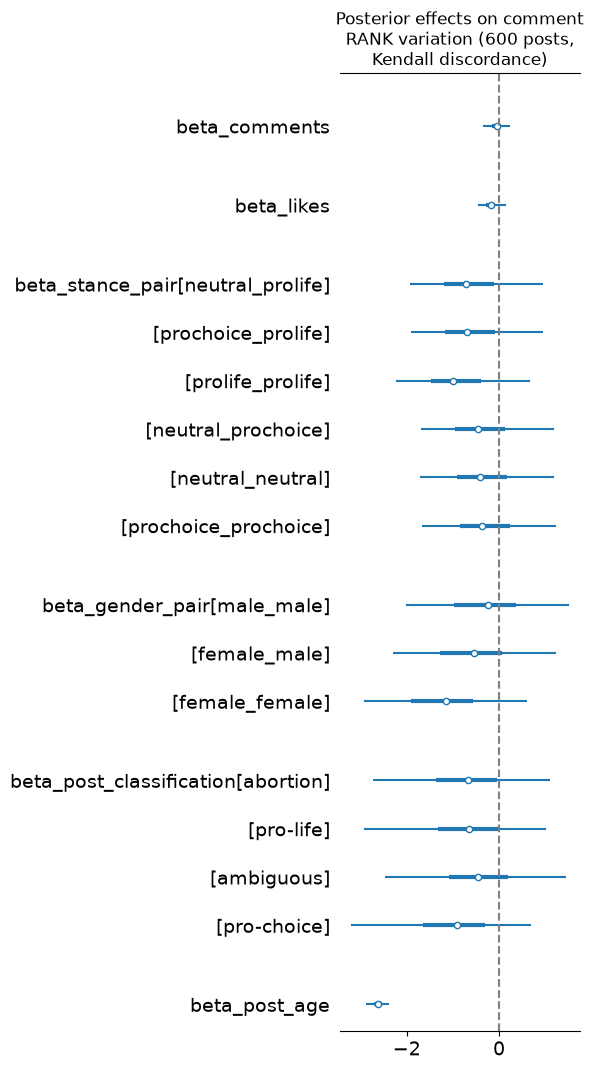

In [ ]:
az.plot_forest(
    rank_trace, var_names=['beta_comments', 'beta_likes',
                       'beta_stance_pair', 'beta_gender_pair', 'beta_post_classification', 'beta_post_age'],
    combined=True, hdi_prob=0.95
)
plt.axvline(0, linestyle='--', color='gray')
plt.title(f"Posterior effects on comment RANK variation ({rank_reg_df['post_id'].nunique()} posts, Kendall discordance)")
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/forest_plot_rank_v2.png', dpi=200)
plt.show()
